In [1]:
import pandas as pd
import seaborn as sns
import re
import matplotlib.pyplot as plt
import os
from matplotlib.patches import Patch
import copy

def split_patches(patches, n, group_size):
    patches_groups = [patches[i * group_size:(i + 1) * group_size] for i in range(n)]    
    baseline_group = patches_groups[0]
    
    return (patches_groups, baseline_group)

def create_speedup_message(patches_groups, baseline_group):
    messages = []
    for pid, p in enumerate(baseline_group):
        baseline_height = baseline_group[pid].get_height()
        message = []
        for group in patches_groups[1:]:
            if group[pid].get_height() > 0:
                speedup = baseline_height / group[pid].get_height()
                message.append(f'{speedup:.1f}x')
        messages.append("/".join(message))
    return messages

# Load the csv files for NES and Apache Flink
df = pd.read_csv("results_nebulastream.csv")

df['system'] = 'NebulaStream'

# Create directory if it doesn't exist
output_dir = 'system_comparison'
os.makedirs(output_dir, exist_ok=True)

# Extract synopsis type and variant from query_name
df["synopsis_type"] = df["query_name"].str.split("_").str[0]
df["query_variant"] = df["query_name"].str.split("_", n=1).str[1]

df

,dataset,statistic_type,statistic_config,build_window_size_sec,bytesPerSecond,query_name,time,tuplesPerSecond,tuplesPerSecond_listener,executionMode,numberOfWorkerThreads,buffersInGlobalBufferManager,joinStrategy,bufferSizeInBytes,pageSize,enableLatency,issue,system,synopsis_type,query_variant
0,Nexmark,Reservoir,100,1,1.713593e+08,Nexmark_ReservoirBuild_100_1sec,38.973751,4.720914e+06,NaN,COMPILER,1,20000,HASH_JOIN,1048576,8192,False,ok,NebulaStream,Nexmark,ReservoirBuild_100_1sec
1,Nexmark,Reservoir,100,1,1.710636e+08,Nexmark_ReservoirBuild_100_1sec,39.041130,4.712766e+06,NaN,COMPILER,1,20000,HASH_JOIN,1048576,8192,False,ok,NebulaStream,Nexmark,ReservoirBuild_100_1sec
2,Nexmark,Reservoir,100,1,1.713448e+08,Nexmark_ReservoirBuild_100_1sec,38.977049,4.720514e+06,NaN,COMPILER,1,20000,HASH_JOIN,1048576,8192,False,ok,NebulaStream,Nexmark,ReservoirBuild_100_1sec
3,Nexmark,Reservoir,100,1,1.692640e+08,Nexmark_ReservoirBuild_100_1sec,39.456191,4.663190e+06,NaN,COMPILER,1,20000,HASH_JOIN,1048576,8192,True,ok,NebulaStream,Nexmark,ReservoirBuild_100_1sec
4,Nexmark,Reservoir,100,1,1.677314e+08,Nexmark_ReservoirBuild_100_1sec,39.816731,4.620965e+06,NaN,COMPILER,1,20000,HASH_JOIN,1048576,8192,True,ok,NebulaStream,Nexmark,ReservoirBuild_100_1sec
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1615,ClusterMonitoring,CountMin,"(10, 10000, uint64)",60,1.749974e+08,ClusterMonitoring_CountMinBuild_10_10000_uint6...,8.730198,2.136155e+06,NaN,COMPILER,16,20000,HASH_JOIN,1048576,8192,False,ok,NebulaStream,ClusterMonitoring,CountMinBuild_10_10000_uint64_60sec
1616,ClusterMonitoring,CountMin,"(10, 10000, uint64)",60,1.739601e+08,ClusterMonitoring_CountMinBuild_10_10000_uint6...,8.782256,2.123493e+06,NaN,COMPILER,16,20000,HASH_JOIN,1048576,8192,False,ok,NebulaStream,ClusterMonitoring,CountMinBuild_10_10000_uint64_60sec
1617,ClusterMonitoring,CountMin,"(10, 10000, uint64)",60,1.710745e+08,ClusterMonitoring_CountMinBuild_10_10000_uint6...,8.930392,2.088269e+06,NaN,COMPILER,16,20000,HASH_JOIN,1048576,8192,True,ok,NebulaStream,ClusterMonitoring,CountMinBuild_10_10000_uint64_60sec
1618,ClusterMonitoring,CountMin,"(10, 10000, uint64)",60,1.720773e+08,ClusterMonitoring_CountMinBuild_10_10000_uint6...,8.878349,2.100509e+06,NaN,COMPILER,16,20000,HASH_JOIN,1048576,8192,True,ok,NebulaStream,ClusterMonitoring,CountMinBuild_10_10000_uint64_60sec


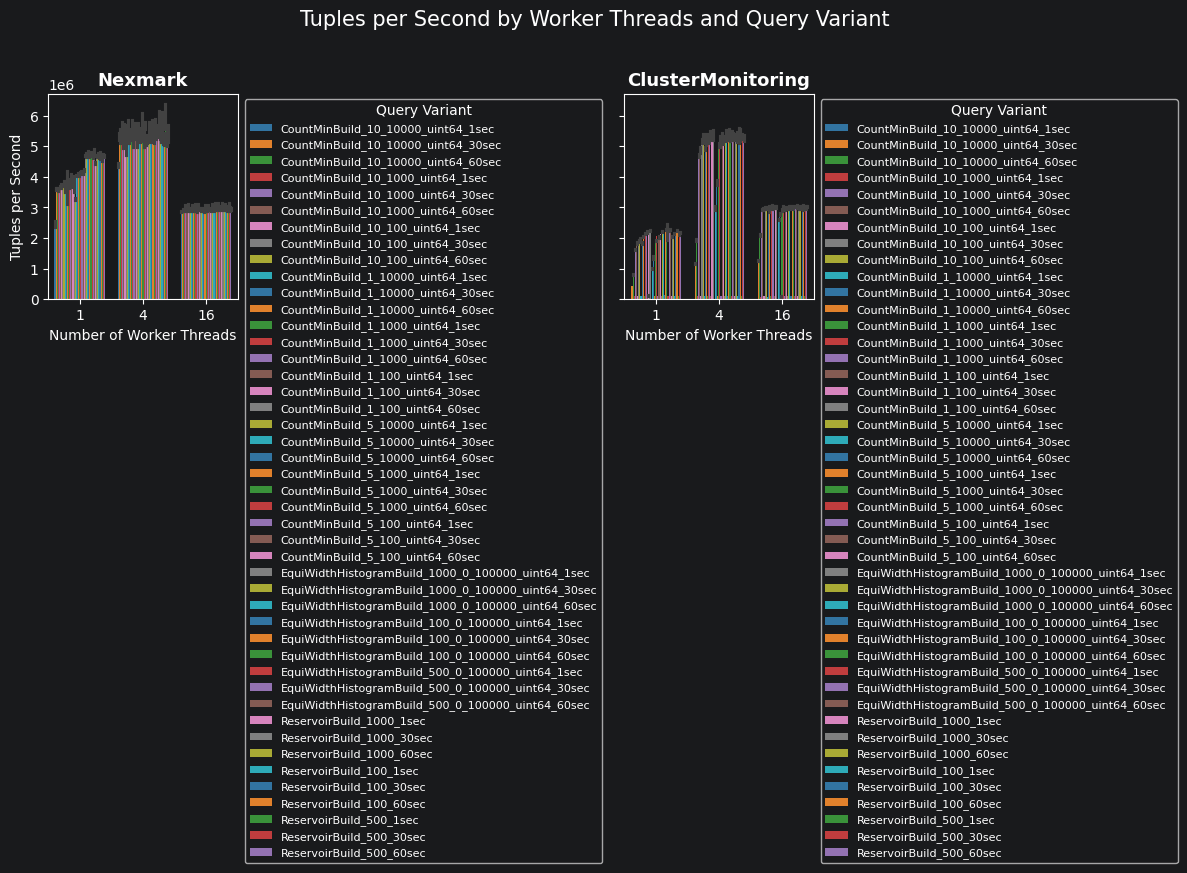

In [2]:
synopsis_types = df["synopsis_type"].unique()
n = len(synopsis_types)

fig, axes = plt.subplots(1, n, figsize=(6 * n, 6), sharey=True)

# Ensure axes is always iterable
if n == 1:
    axes = [axes]

for ax, synopsis in zip(axes, synopsis_types):
    subset = df[df["synopsis_type"] == synopsis]
    hue_order = sorted(subset["query_variant"].dropna().unique())
    palette = sns.color_palette("tab10", len(hue_order))

    sns.barplot(
        data=subset,
        x="numberOfWorkerThreads",
        y="tuplesPerSecond",
        hue="query_variant",
        hue_order=hue_order,
        palette=palette,
        ax=ax,
        errorbar="sd",       # show standard deviation as error bars; use None to disable
    )

    ax.set_title(synopsis, fontsize=13, fontweight="bold")
    ax.set_xlabel("Number of Worker Threads")
    ax.set_ylabel("Tuples per Second" if ax == axes[0] else "")
    ax.legend(title="Query Variant", bbox_to_anchor=(1.01, 1), loc="upper left", fontsize=8)

fig.suptitle("Tuples per Second by Worker Threads and Query Variant", fontsize=15, y=1.02)
plt.tight_layout()
plt.show()

[numberOfWorkerThreads] Config: dataset=ClusterMonitoring, statistic_type=CountMin, statistic_config=(1, 10000, uint64), build_window_size_sec=1, enableLatency=False
  Missing ok for numberOfWorkerThreads=[np.int64(16)] (expected: [np.int64(1), np.int64(4), np.int64(16)])
  Explicit failure(s): ['crashed (SIGABRT)'] at numberOfWorkerThreads=[np.int64(16)] (3 failed rows)
  Excluding 6 ok (collateral) + 3 failed rows

[numberOfWorkerThreads] Config: dataset=ClusterMonitoring, statistic_type=CountMin, statistic_config=(10, 1000, uint64), build_window_size_sec=1, enableLatency=True
  Missing ok for numberOfWorkerThreads=[np.int64(16)] (expected: [np.int64(1), np.int64(4), np.int64(16)])
  Explicit failure(s): ['crashed (SIGABRT)', 'oom_killed'] at numberOfWorkerThreads=[np.int64(16)] (3 failed rows)
  Excluding 6 ok (collateral) + 3 failed rows

[numberOfWorkerThreads] Config: dataset=ClusterMonitoring, statistic_type=CountMin, statistic_config=(10, 10000, uint64), build_window_size_sec=1

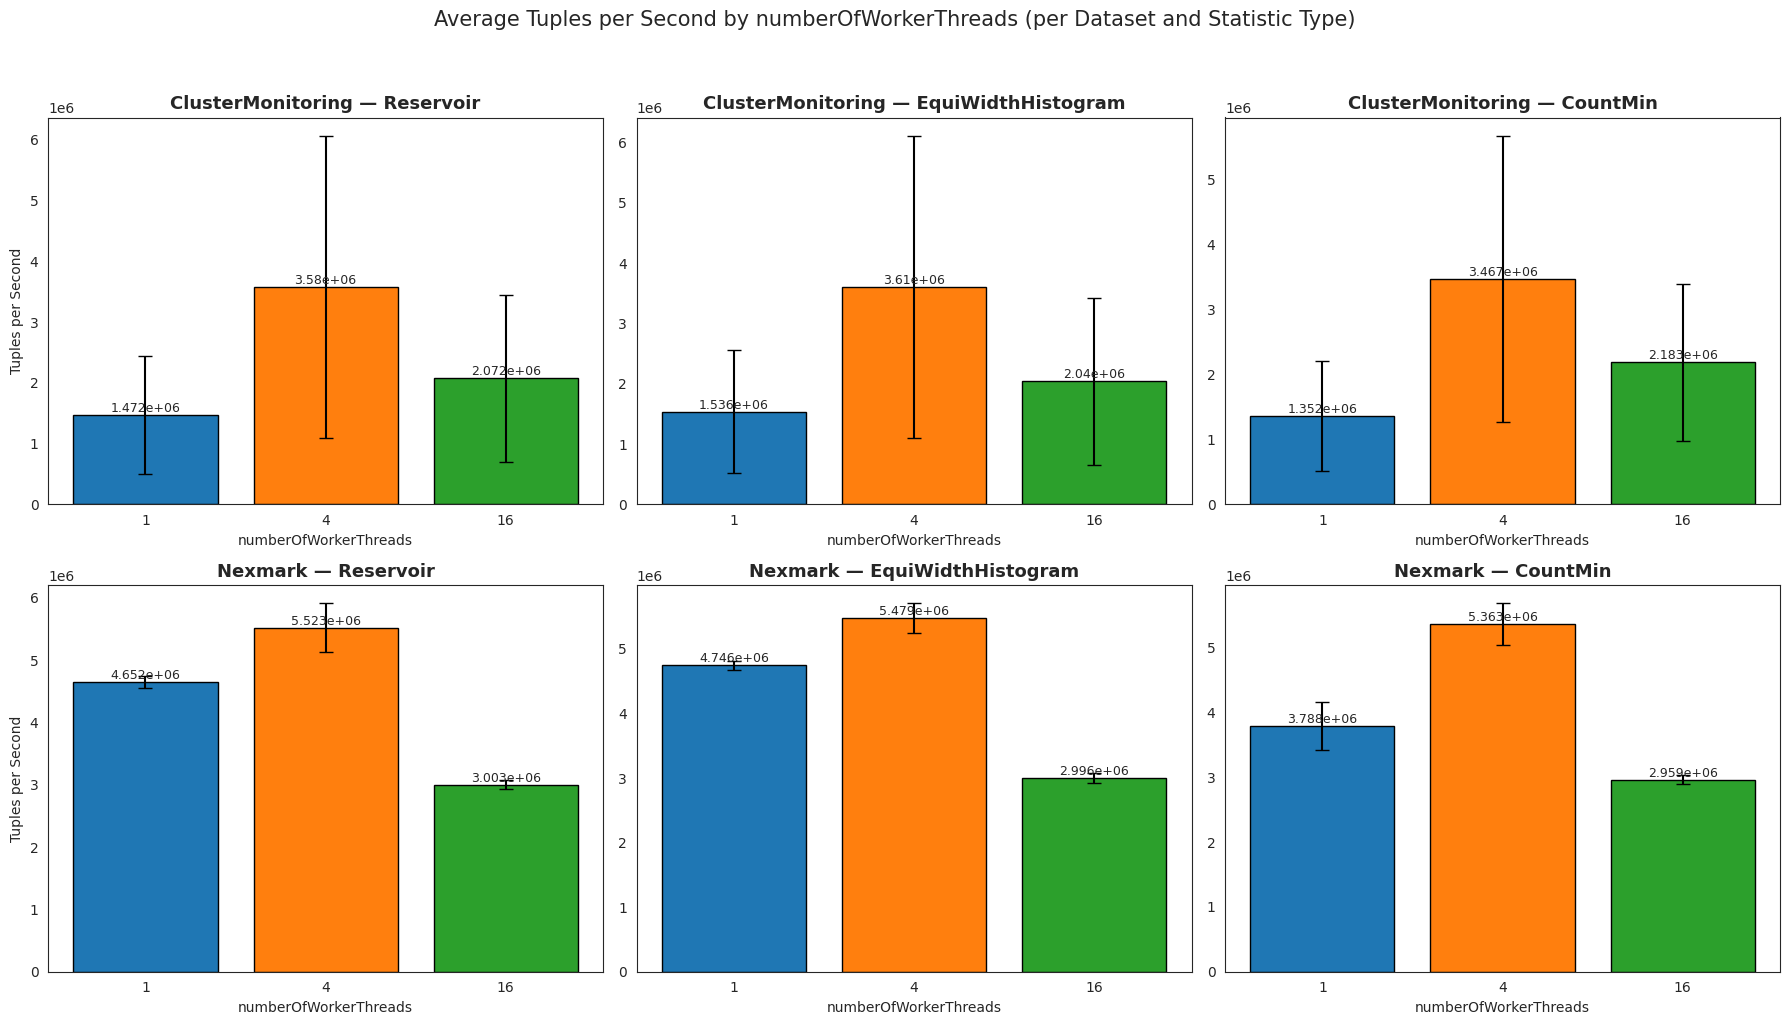

[numberOfWorkerThreads] Config: dataset=ClusterMonitoring, statistic_type=CountMin, statistic_config=(1, 10000, uint64), build_window_size_sec=1, enableLatency=False
  Missing ok for numberOfWorkerThreads=[np.int64(16)] (expected: [np.int64(1), np.int64(4), np.int64(16)])
  Explicit failure(s): ['crashed (SIGABRT)'] at numberOfWorkerThreads=[np.int64(16)] (3 failed rows)
  Excluding 6 ok (collateral) + 3 failed rows

[numberOfWorkerThreads] Config: dataset=ClusterMonitoring, statistic_type=CountMin, statistic_config=(10, 1000, uint64), build_window_size_sec=1, enableLatency=True
  Missing ok for numberOfWorkerThreads=[np.int64(16)] (expected: [np.int64(1), np.int64(4), np.int64(16)])
  Explicit failure(s): ['crashed (SIGABRT)', 'oom_killed'] at numberOfWorkerThreads=[np.int64(16)] (3 failed rows)
  Excluding 6 ok (collateral) + 3 failed rows

[numberOfWorkerThreads] Config: dataset=ClusterMonitoring, statistic_type=CountMin, statistic_config=(10, 10000, uint64), build_window_size_sec=1

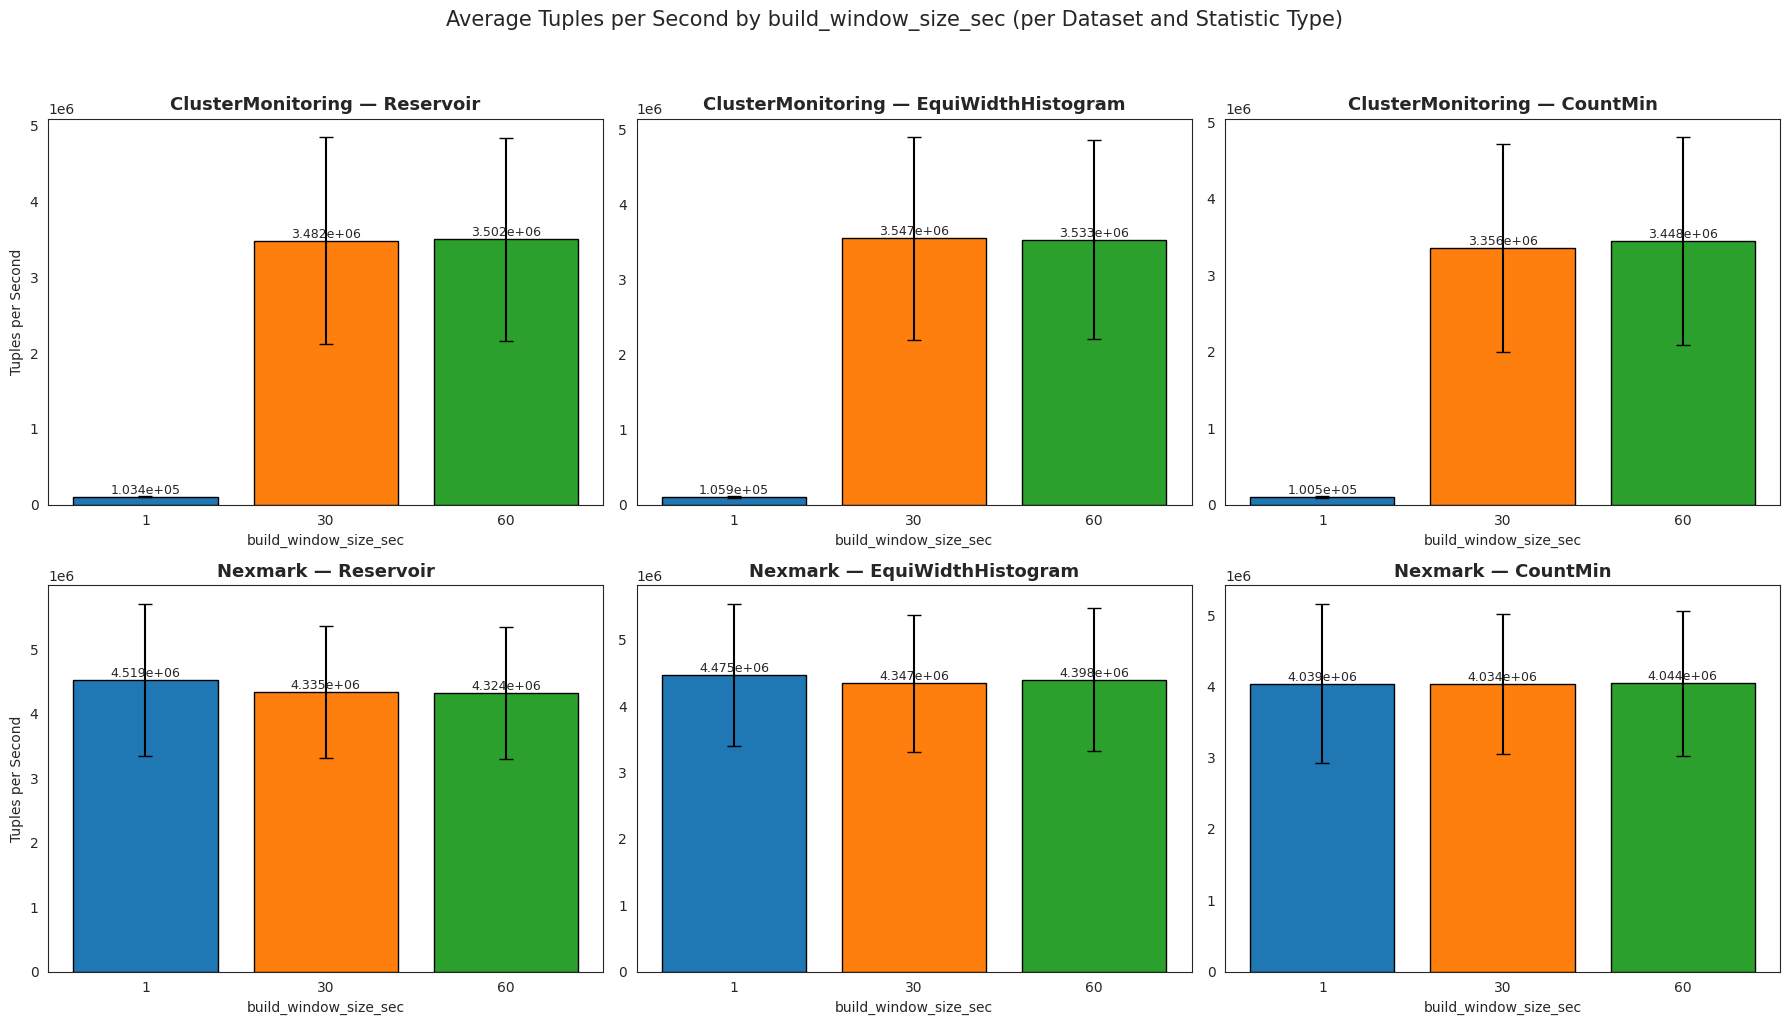

[build_window_size_sec] Config: dataset=ClusterMonitoring, statistic_type=CountMin, statistic_config=(1, 10000, uint64), numberOfWorkerThreads=16, enableLatency=False
  Missing ok for build_window_size_sec=[np.int64(1)] (expected: [np.int64(1), np.int64(30), np.int64(60)])
  Explicit failure(s): ['crashed (SIGABRT)'] at build_window_size_sec=[np.int64(1)] (3 failed rows)
  Excluding 6 ok (collateral) + 3 failed rows

[build_window_size_sec] Config: dataset=ClusterMonitoring, statistic_type=CountMin, statistic_config=(10, 1000, uint64), numberOfWorkerThreads=16, enableLatency=True
  Missing ok for build_window_size_sec=[np.int64(1)] (expected: [np.int64(1), np.int64(30), np.int64(60)])
  Explicit failure(s): ['crashed (SIGABRT)', 'oom_killed'] at build_window_size_sec=[np.int64(1)] (3 failed rows)
  Excluding 6 ok (collateral) + 3 failed rows

[build_window_size_sec] Config: dataset=ClusterMonitoring, statistic_type=CountMin, statistic_config=(10, 10000, uint64), numberOfWorkerThreads=1

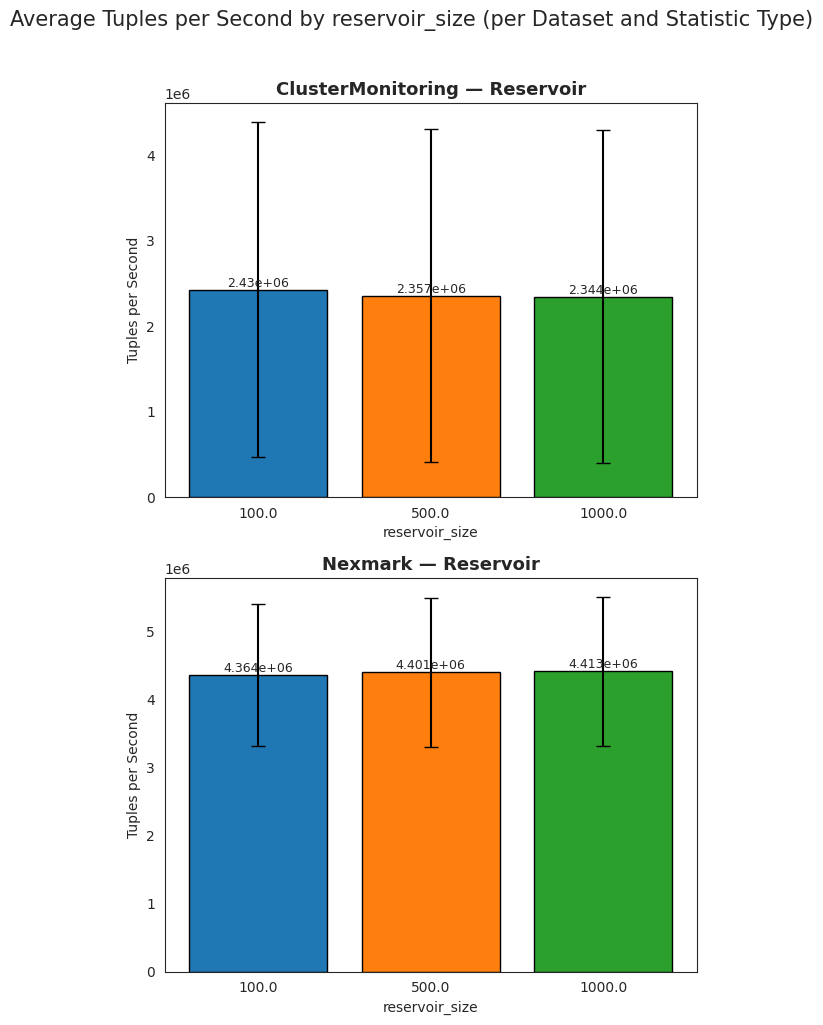

[reservoir_size/latency_listener] Column not present in data, skipping plot.


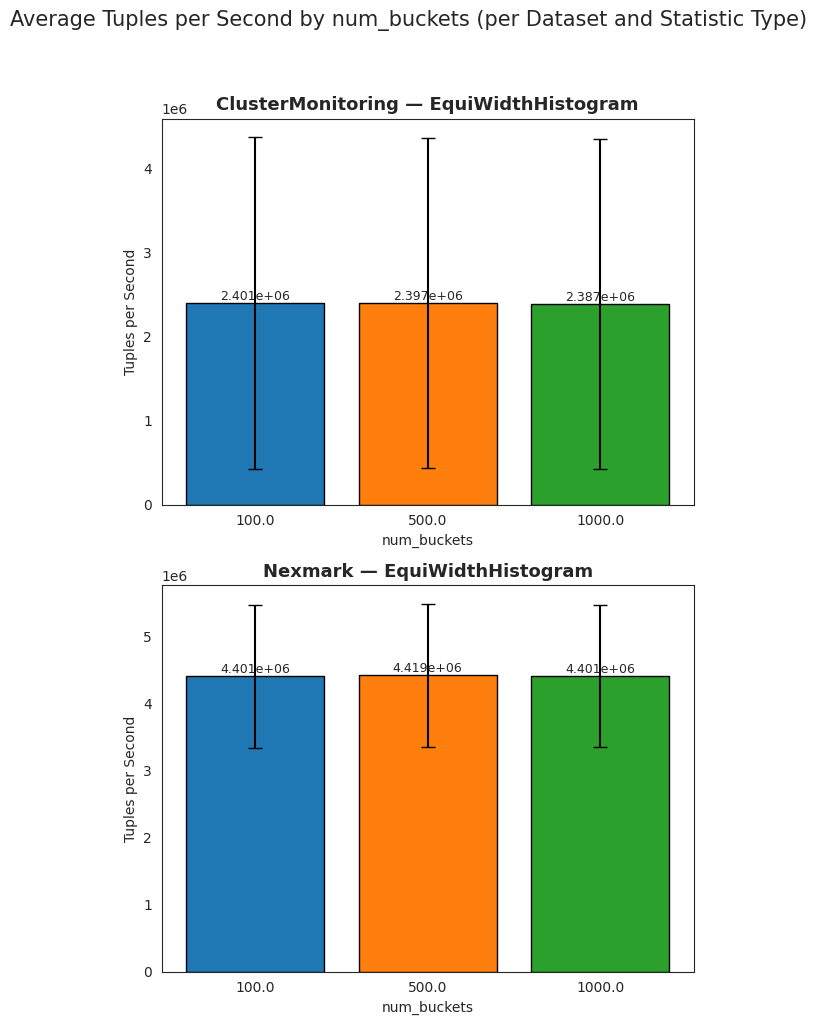

[num_buckets/latency_listener] Column not present in data, skipping plot.


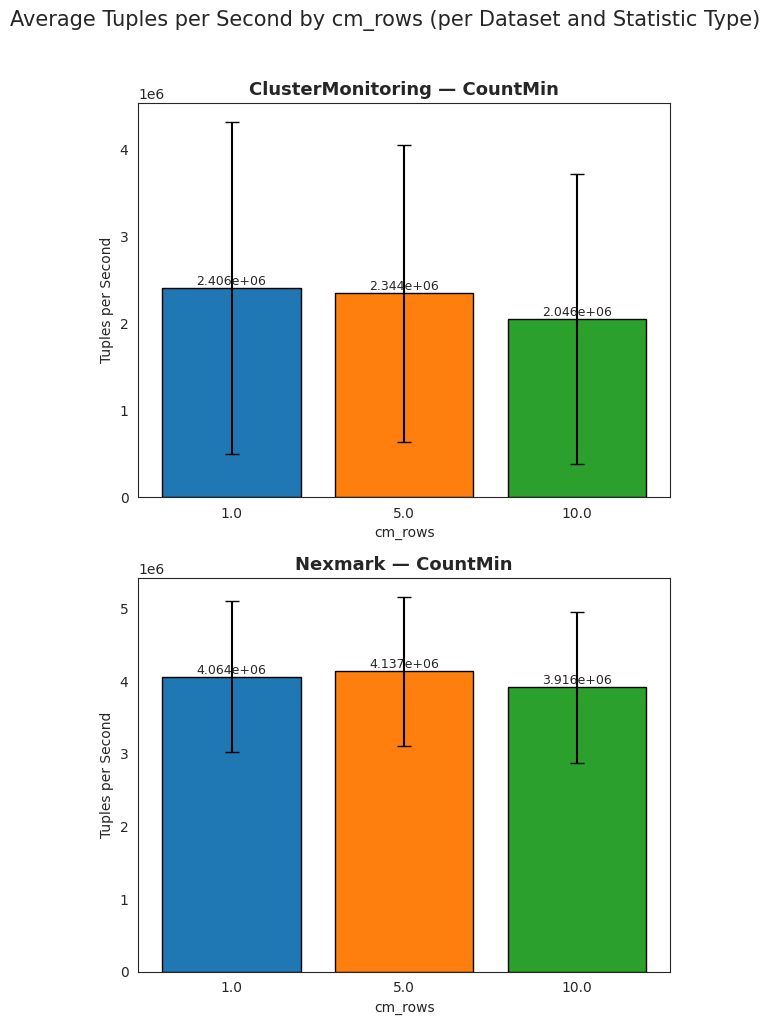

[cm_rows/latency_listener] Column not present in data, skipping plot.
[cm_cols] Config: dataset=ClusterMonitoring, statistic_type=CountMin, build_window_size_sec=1, numberOfWorkerThreads=16, enableLatency=False
  Missing ok for cm_cols=[np.float64(10000.0)] (expected: [np.float64(100.0), np.float64(1000.0), np.float64(10000.0)])
  Explicit failure(s): ['crashed (SIGABRT)', 'oom_killed'] at cm_cols=[np.float64(10000.0)] (11 failed rows)
  Excluding 16 ok (collateral) + 11 failed rows

[cm_cols] Total: excluded 27 rows (11 failed + 16 ok collateral + 0 missing combinations), 945 remaining
---


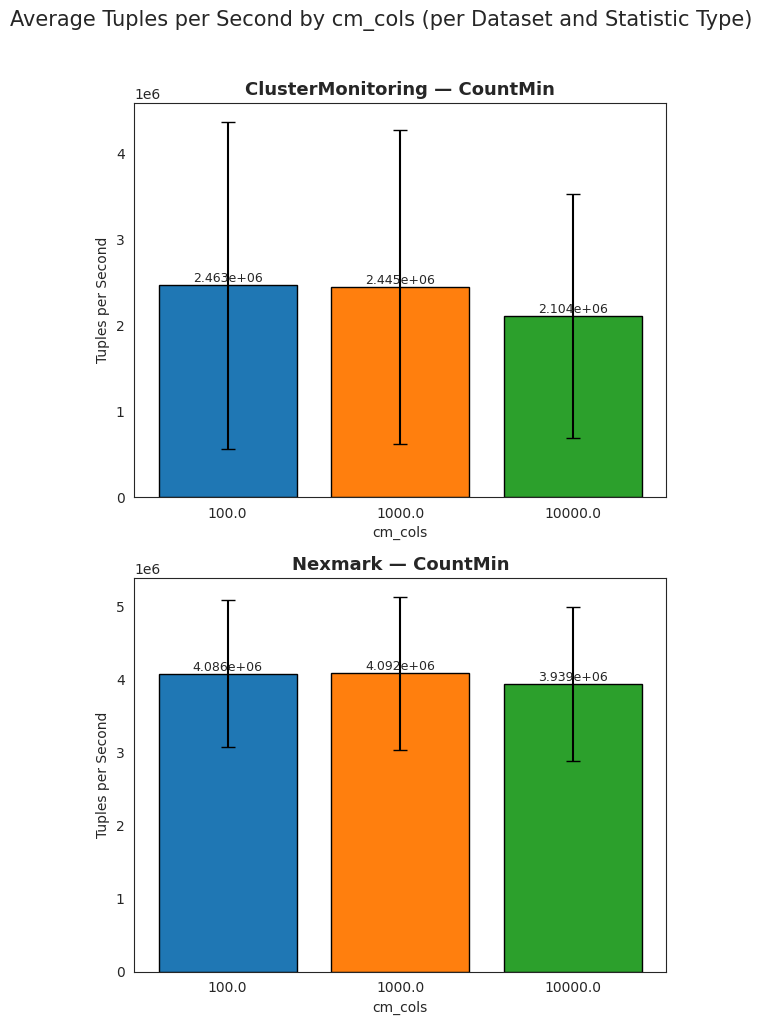

[cm_cols] Config: dataset=ClusterMonitoring, statistic_type=CountMin, build_window_size_sec=1, numberOfWorkerThreads=16, enableLatency=False
  Missing ok for cm_cols=[np.float64(10000.0)] (expected: [np.float64(100.0), np.float64(1000.0), np.float64(10000.0)])
  Explicit failure(s): ['crashed (SIGABRT)', 'oom_killed'] at cm_cols=[np.float64(10000.0)] (11 failed rows)
  Excluding 16 ok (collateral) + 11 failed rows

[cm_cols] Total: excluded 27 rows (11 failed + 16 ok collateral + 0 missing combinations), 945 remaining
---
[cm_cols/latency_listener] Column not present in data, skipping plot.


In [3]:
# Columns that together define a unique experiment configuration
CONFIG_COLS = ["dataset", "statistic_type", "statistic_config", "build_window_size_sec", "numberOfWorkerThreads", "enableLatency"]

def filter_failed_configs(df, iterate_param):
    """
    Exclude all runs whose config (ignoring `iterate_param`) does not have an "ok"
    row for every value of `iterate_param` present in the dataset.

    This catches both explicit failures (issue != "ok") and missing rows caused by
    crashes that produced no CSV output at all — either way the config group is dropped
    so results are never skewed by an incomplete parameter sweep.

    When `iterate_param` is a derived column (e.g. reservoir_size, cm_rows) that is
    not itself in CONFIG_COLS but is encoded by statistic_config, statistic_config is
    also removed from key_cols so that configs with different statistic_config values
    are grouped together and can cross-check each other.
    """
    key_cols = [c for c in CONFIG_COLS if c != iterate_param]
    # Derived params (reservoir_size, cm_rows, …) are encoded in statistic_config.
    # Keeping statistic_config in key_cols would put each derived value in its own
    # group, making cross-value coverage checks impossible.
    if iterate_param not in CONFIG_COLS:
        key_cols = [c for c in key_cols if c != "statistic_config"]

    all_param_values = set(df[iterate_param].dropna().unique())

    # For each config group, check that every iterate_param value has >= 1 "ok" row
    def has_full_ok_coverage(group):
        ok_vals = set(group.loc[group["issue"] == "ok", iterate_param].dropna())
        return all_param_values.issubset(ok_vals)

    coverage = df.groupby(key_cols, group_keys=False).apply(has_full_ok_coverage)
    bad_index = coverage[~coverage].index

    if len(bad_index) == 0:
        return df

    # Reconstruct bad config keys as a DataFrame for merging
    if isinstance(bad_index, pd.MultiIndex):
        bad_keys = bad_index.to_frame(index=False)
    else:
        bad_keys = pd.DataFrame({key_cols[0]: bad_index})

    # Print details and accumulate summary counts
    total_failed = 0
    total_ok_collateral = 0
    total_missing_combos = 0

    for _, bkey in bad_keys.iterrows():
        mask = (df[key_cols] == bkey.values).all(axis=1)
        config_rows = df[mask]

        failed_rows = config_rows[config_rows["issue"] != "ok"]
        ok_rows = config_rows[config_rows["issue"] == "ok"]

        ok_vals = set(ok_rows[iterate_param].dropna())
        failed_vals = set(failed_rows[iterate_param].dropna())
        present_vals = set(config_rows[iterate_param].dropna())
        missing_vals = sorted(all_param_values - ok_vals)
        absent_vals = sorted(all_param_values - present_vals)   # no row at all
        explicit_fail_vals = sorted(failed_vals & (all_param_values - ok_vals))

        n_missing_combos = len(absent_vals)
        total_failed += len(failed_rows)
        total_ok_collateral += len(ok_rows)
        total_missing_combos += n_missing_combos

        config_str = ", ".join(f"{c}={bkey[c]}" for c in key_cols)
        print(f"[{iterate_param}] Config: {config_str}")
        print(f"  Missing ok for {iterate_param}={missing_vals} (expected: {sorted(all_param_values)})")
        if explicit_fail_vals:
            issues = failed_rows[failed_rows[iterate_param].isin(explicit_fail_vals)]["issue"].unique()
            print(f"  Explicit failure(s): {list(issues)} at {iterate_param}={explicit_fail_vals} ({len(failed_rows)} failed rows)")
        if absent_vals:
            print(f"  No rows at all for {iterate_param}={absent_vals} ({n_missing_combos} missing combination(s))")
        print(f"  Excluding {len(ok_rows)} ok (collateral) + {len(failed_rows)} failed rows")
        print()

    # Drop all rows belonging to incomplete config groups
    merged = df.merge(bad_keys, on=key_cols, how="left", indicator=True)
    clean = merged[merged["_merge"] == "left_only"].drop(columns="_merge")

    n_dropped = len(df) - len(clean)
    print(f"[{iterate_param}] Total: excluded {n_dropped} rows "
          f"({total_failed} failed + {total_ok_collateral} ok collateral + {total_missing_combos} missing combinations), "
          f"{len(clean)} remaining")
    print("---")

    return clean

_METRIC_LABEL = {
    "tuplesPerSecond":          "Tuples per Second",
    "tuplesPerSecond_listener": "Tuples per Second (listener)",
    "bytesPerSecond":           "Bytes per Second",
    "latency_listener":         "Avg Latency (s)",
}

def plot_avg_by(df, param, metric="tuplesPerSecond"):
    """Bar chart of avg `metric` per (dataset, statistic type), grouped by `param`.

    For latency_listener, rows with value -1 (no measurements) are excluded before
    aggregation. If no data remains after that filter the subplot is skipped.
    """
    df_clean = filter_failed_configs(df, param)

    if df_clean.empty:
        print(f"[{param}/{metric}] No data remaining after filtering, skipping plot.")
        return

    if metric == "latency_listener":
        if metric not in df_clean.columns:
            print(f"[{param}/latency_listener] Column not present in data, skipping plot.")
            return
        # Only include runs where the latency listener was actually enabled
        df_clean = df_clean[df_clean["enableLatency"] == True].copy()
        # Drop sentinel -1 values (listener enabled but produced no measurements)
        df_clean = df_clean[pd.to_numeric(df_clean[metric], errors="coerce").fillna(-1) != -1]
        if df_clean.empty:
            print(f"[{param}/latency_listener] No latency data available, skipping plot.")
            return

    ylabel = _METRIC_LABEL.get(metric, metric)
    suptitle = f"Average {ylabel} by {param} (per Dataset and Statistic Type)"

    datasets = sorted(df_clean["dataset"].unique())
    statistic_types = df_clean["statistic_type"].unique()
    n_datasets = len(datasets)
    n_stats = len(statistic_types)

    with sns.axes_style("white"):
        fig, axes = plt.subplots(
            n_datasets, n_stats,
            figsize=(6 * n_stats, 5 * n_datasets),
            sharey=False,
            squeeze=False,
        )

        for row, dataset in enumerate(datasets):
            df_ds = df_clean[df_clean["dataset"] == dataset]
            for col, stat_type in enumerate(statistic_types):
                ax = axes[row][col]
                subset = df_ds[df_ds["statistic_type"] == stat_type].copy()
                subset[metric] = pd.to_numeric(subset[metric], errors="coerce")
                subset = subset.dropna(subset=[metric])

                if subset.empty:
                    ax.set_visible(False)
                    continue

                avg = subset.groupby(param)[metric].agg(["mean", "std"]).reset_index()
                avg = avg.sort_values(param)

                bars = ax.bar(
                    avg[param].astype(str),
                    avg["mean"],
                    yerr=avg["std"],
                    capsize=5,
                    color=sns.color_palette("tab10", len(avg)),
                    edgecolor="black",
                )

                ax.set_ylim(bottom=0)
                ax.set_xlabel(param)
                ax.set_ylabel(ylabel if col == 0 else "")
                ax.set_title(f"{dataset} — {stat_type}", fontsize=13, fontweight="bold")

                for bar in bars:
                    height = bar.get_height()
                    ax.text(bar.get_x() + bar.get_width() / 2, height, f"{height:,.4g}",
                            ha="center", va="bottom", fontsize=9)

        fig.suptitle(suptitle, fontsize=15, y=1.02)
        plt.tight_layout()
        plt.show()

# Parse statistic_config into dedicated columns per statistic type
# Reservoir: config is just the reservoir size
mask_res = df["statistic_type"] == "Reservoir"
df.loc[mask_res, "reservoir_size"] = df.loc[mask_res, "statistic_config"].astype(int)

# EquiWidthHistogram: "(num_buckets, min_value, max_value, counter_type)"
mask_hist = df["statistic_type"] == "EquiWidthHistogram"
df.loc[mask_hist, "num_buckets"] = (
    df.loc[mask_hist, "statistic_config"]
    .str.extract(r"\((\d+),")[0].astype(int)
)

# CountMin: "(rows, cols, counter_type)"
mask_cm = df["statistic_type"] == "CountMin"
cm_parts = df.loc[mask_cm, "statistic_config"].str.extract(r"\((\d+),\s*(\d+),")
df.loc[mask_cm, "cm_rows"] = cm_parts[0].astype(int)
df.loc[mask_cm, "cm_cols"] = cm_parts[1].astype(int)

# Common plots for all statistic types
plot_avg_by(df, "numberOfWorkerThreads")
plot_avg_by(df, "numberOfWorkerThreads", metric="latency_listener")

plot_avg_by(df, "build_window_size_sec")
plot_avg_by(df, "build_window_size_sec", metric="latency_listener")

# Per-statistic-type config plots
plot_avg_by(df[mask_res], "reservoir_size")
plot_avg_by(df[mask_res], "reservoir_size", metric="latency_listener")

plot_avg_by(df[mask_hist], "num_buckets")
plot_avg_by(df[mask_hist], "num_buckets", metric="latency_listener")

plot_avg_by(df[mask_cm], "cm_rows")
plot_avg_by(df[mask_cm], "cm_rows", metric="latency_listener")

plot_avg_by(df[mask_cm], "cm_cols")
plot_avg_by(df[mask_cm], "cm_cols", metric="latency_listener")